---
title: "DOW 6: Looking into the recent trend of Matcha Lattes"
author: Emilie 
date: 4/1/2026
categories:
  - DOW
  - Google Search Trends  
  - Matcha 
  - Starbucks
---

# Looking into the recent trend of Matcha Lattes:

![](images/latte.jpg){width=500}

In recent years, matcha lattes have evolved from just a beverage to a this HUGE internet phenomenom. Matcha is now a lifestyle, with it being an effective replacement of everyday coffee. Since the start of this year, it seems the popularity of matcha lattes has been exploding. Does the general public's interest in matcha seem or has there been a plateu? But is this popularity actually reflected in public interest?

To answer these questions, I analyzed Google Trends data for the search term “matcha latte” in the United States over the past 12 months. Google Trends measures relative search popularity on a scale from 0 to 100. I also looked into a dataset documenting Starbucks match-related product releases to see if there is any association with overall internet spikes. 

By comparing these datasets, I wanted to explore whether the expansion of Starbucks’ matcha offerings aligned with increased public search interest.

Let's look at what I found. 

![](images/google.png){width=500}

## First, Google Search Trends Data

Before beginning the analysis, I first inspected the structure of the dataset to better understand what kind of data was being loaded into Python.

In [45]:
import pandas as pd
import time
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [4]:
matcha_df.shape

(53, 2)

This means the dataset contains 53 rows and 2 columns.

In [3]:
matcha_df = pd.read_csv('data/trends.csv')

In [14]:
matcha_df.index

DatetimeIndex(['2025-05-18', '2025-05-25', '2025-06-01', '2025-06-08',
               '2025-06-15', '2025-06-22', '2025-06-29', '2025-07-06',
               '2025-07-13', '2025-07-20', '2025-07-27', '2025-08-03',
               '2025-08-10', '2025-08-17', '2025-08-24', '2025-08-31',
               '2025-09-07', '2025-09-14', '2025-09-21', '2025-09-28',
               '2025-10-05', '2025-10-12', '2025-10-19', '2025-10-26',
               '2025-11-02', '2025-11-09', '2025-11-16', '2025-11-23',
               '2025-11-30', '2025-12-07', '2025-12-14', '2025-12-21',
               '2025-12-28', '2026-01-04', '2026-01-11', '2026-01-18',
               '2026-01-25', '2026-02-01', '2026-02-08', '2026-02-15',
               '2026-02-22', '2026-03-01', '2026-03-08', '2026-03-15',
               '2026-03-22', '2026-03-29', '2026-04-05', '2026-04-12',
               '2026-04-19', '2026-04-26', '2026-05-03'],
              dtype='datetime64[us]', name='2025-05-11', freq=None)

This returned a DatetimeIndex, meaning pandas successfully recognized the dates as datetime objects rather than plain text strings.

In [44]:
matcha_df = pd.read_csv('data/trends.csv',
                       skiprows=2,
                       index_col=0,
                       parse_dates=True
                      )

![](images/matcha_latte.jpg){width=300}

## Overall visualization of the Google Search Trends for Matcha Latte 

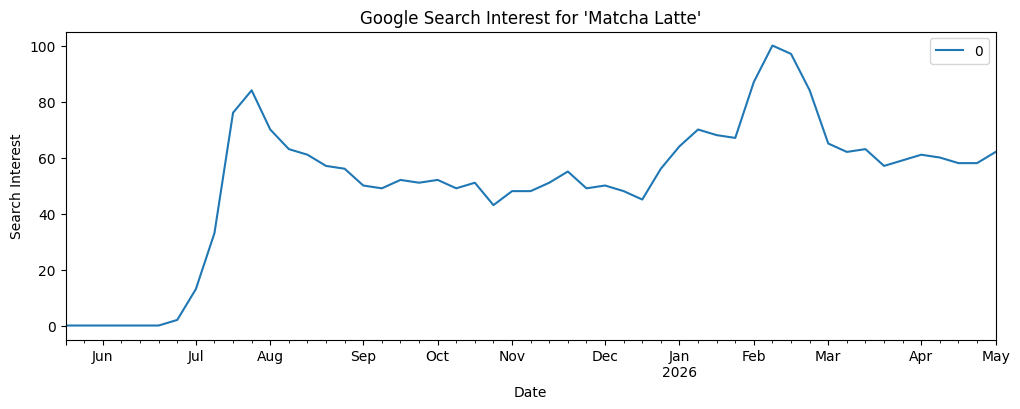

In [49]:
ts_plot = matcha_df.plot(figsize=(12,4))

plt.title("Google Search Interest for 'Matcha Latte'")
plt.xlabel("Date")
plt.ylabel("Search Interest")

plt.show()

The data appears to show two different phases of matcha popularity:

- initial breakout period during summer 2025
- larger mainstream surge during early 2026

This pattern may indicate that public awareness of matcha continued to grow over time rather than fading after the first spike in interest.

Let's head into another analysis ---> 

## Resampling data for Monthly Average of Matcha Search Interest

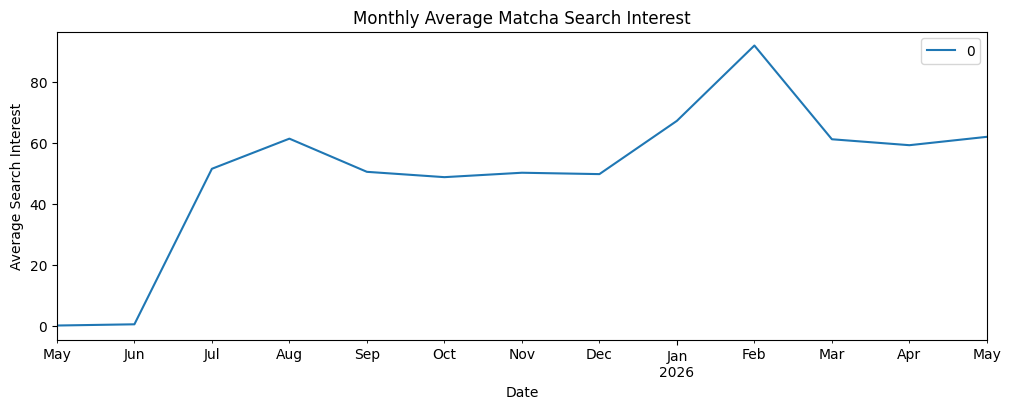

In [43]:
month_plot = matcha_df.resample('ME').mean().plot(figsize=(12,4))

plt.title("Monthly Average Matcha Search Interest")
plt.xlabel("Date")
plt.ylabel("Average Search Interest")

plt.show()

**Findings:**  Resampling the Google Trends data into monthly averages makes the broader trajectory of matcha search interest much easier to identify. Rather than focusing on week-to-week fluctuations, the monthly averages highlight larger patterns in public attention over time.

The graph shows that search interest for “matcha latte” remained very low during May and June before sharply increasing in July. Interest then stayed relatively steady throughout the fall before reaching its highest point in February 2026.

One possible explanation for this spike is the connection between matcha and New Year wellness trends, as consumers often search for healthier lifestyle options early in the year. Even after the February peak, search interest remained much higher than it was at the beginning of the dataset, suggesting that matcha’s popularity became more sustained over time.

## 21-Day Rolling Average of Matcha Searches 

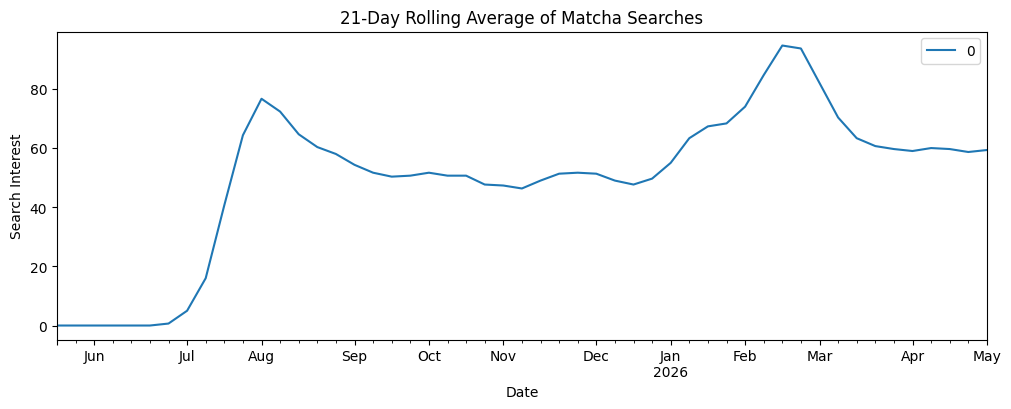

In [22]:
matcha_df.rolling('21D').mean().plot(figsize=(12,4))

plt.title("21-Day Rolling Average of Matcha Searches")
plt.xlabel("Date")
plt.ylabel("Search Interest")

plt.show()

**Findings:** The 21-day rolling average smooths out short-term fluctuations in the data, making the long-term trend in matcha search interest easier to identify. Rather than focusing on individual weekly spikes, the rolling average highlights more sustained changes. 

The graph shows a sharp rise in search interest during July and August 2025 before gradually declining throughout the fall. Interest begins increasing again in early 2026 and reaches its highest sustained level in February.

Unlike the original graph, the rolling average makes it clear that matcha maintained relatively strong search interest even after major spikes declined. This suggests that public attention toward matcha became more consistent over time rather than disappearing as a short viral moment. 

## Now heading into the Starbucks Data Set

![](images/starbucks.jpeg){width=500}

In [30]:
starbucks_df = pd.read_csv(
    'data/starbucks.csv',
    on_bad_lines='skip',
    parse_dates=['Date']
)

### All of matcha related products in Starbuck's menu history including dates

In [36]:
starbucks_df.head(19)

,Date,Item,Type,Notes,Status,Year
0,2001-01-01,Tazo Green Tea Frappuccino Blended Creme,Beverage,First introduced in Starbucks stores in Taiwan...,Discontinued,2001
1,2005-07-13,Tazo Green Tea Frappuccino Blended Creme (US/C...,Beverage,Limited-time launch in US and Canada (availabl...,Discontinued,2005
2,2005-07-13,Tazo Shaken Green Iced Tea,Beverage,Limited-time launch in US and Canada (through ...,Discontinued,2005
3,2005-07-13,Tazo Shaken Green Tea Lemonade,Beverage,Limited-time launch in US and Canada (through ...,Discontinued,2005
4,2006-04-04,Tazo Green Tea Latte (Hot Matcha Latte),Beverage,Officially launched as a year-round menu item;...,Active (rebranded as Matcha Latte),2006
5,2006-04-04,Green Tea Crème Frappuccino,Beverage,Launched as a year-round item alongside the Gr...,Active (rebranded as Matcha Crème Frappuccino),2006
6,2006-04-04,Blackberry Green Tea Frappuccino Blended Creme,Beverage,"Seasonal/limited-time launch (through Aug 30, ...",Discontinued,2006
7,2006-04-04,Iced Matcha Green Tea Latte,Beverage,Iced version of the Green Tea Latte added to y...,Active,2006
8,2025-01-02,Unsweetened Matcha Powder Formula,Ingredient Change,Starbucks switched to unsweetened matcha powde...,Active,2025
9,2025-03-04,Iced Lavender Cream Oatmilk Matcha,Beverage,Spring seasonal launch; lavender cold foam ove...,Seasonal,2025


### Starbucks Matcha Product Releases by Year

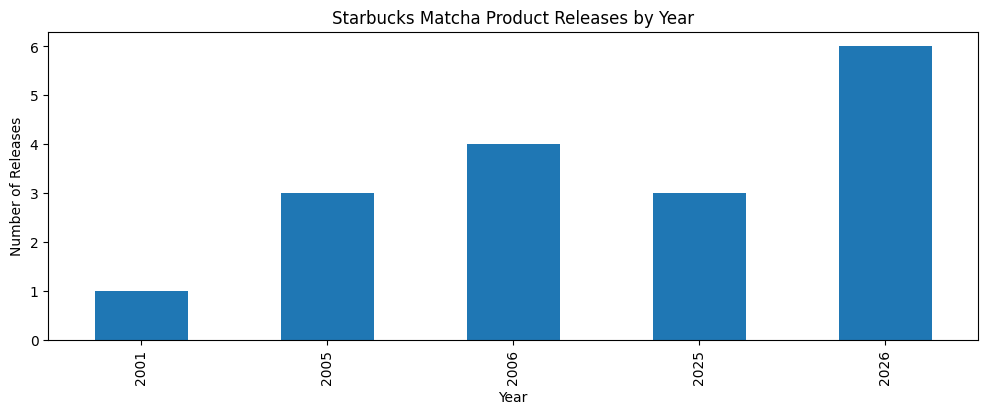

In [33]:
starbucks_df['Year'] = starbucks_df['Date'].dt.year

release_counts = starbucks_df.groupby('Year').size()

release_counts.plot(kind='bar', figsize=(12,4))

plt.title("Starbucks Matcha Product Releases by Year")
plt.xlabel("Year")
plt.ylabel("Number of Releases")

plt.show()

The graph shows relatively few matcha-related releases during the early 2000s, suggesting that matcha was initially treated as a more niche menu item. However, the number of releases increases substantially by 2025 and 2026, with 2026 showing the highest number of matcha product launches.

### Starbucks Matcha Releases by Month

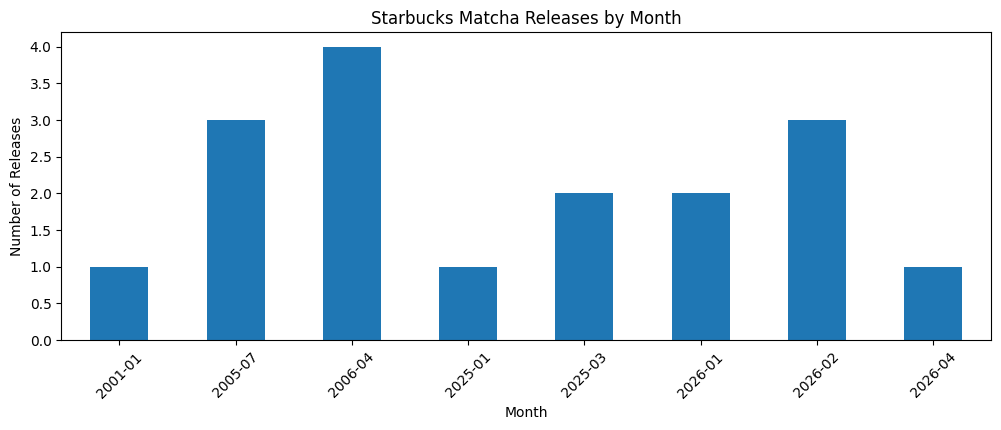

In [42]:
starbucks_df['YearMonth'] = starbucks_df['Date'].dt.strftime('%Y-%m')

monthly_releases = starbucks_df.groupby('YearMonth').size()

monthly_releases.plot(kind='bar', figsize=(12,4))

plt.title("Starbucks Matcha Releases by Month")
plt.xlabel("Month")
plt.ylabel("Number of Releases")

plt.xticks(rotation=45)

plt.show()

The graph shows that releases were relatively scattered during the early 2000s, with only occasional matcha-related launches. However, releases become more frequent during 2025 and especially early 2026.

One of the most noticeable patterns is the concentration of releases around January through April 2026, particularly February 2026. This period aligns closely with the spike in Google search interest for “matcha latte” seen in the Google Trends analysis.

### Combined analysis of Google Trends and Starbucks Matcha Related Releases

In [34]:
release_dates = starbucks_df['Date']

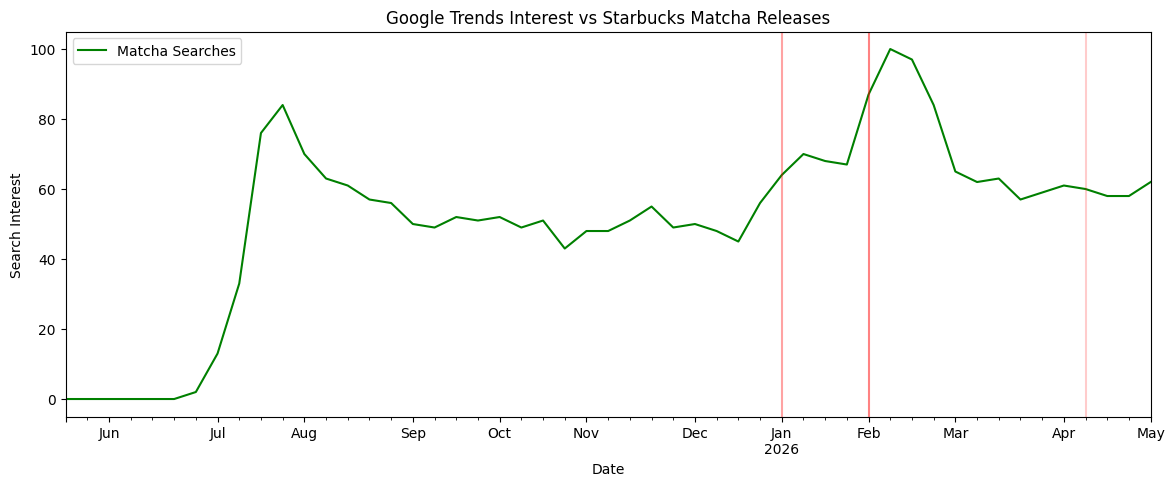

In [35]:
fig, ax = plt.subplots(figsize=(14,5))

matcha_df.plot(ax=ax, color='green')

for date in release_dates:
    ax.axvline(date, color='red', alpha=0.2)

plt.title("Google Trends Interest vs Starbucks Matcha Releases")
plt.xlabel("Date")
plt.ylabel("Search Interest")

plt.legend(["Matcha Searches"])

plt.show()

**Findings:** The combined visualization shows a relationship between Google search interest for “matcha latte” and Starbucks matcha product releases. The red vertical lines represent Starbucks release dates, while the green line tracks Google search interest over time.

Several Starbucks releases occur during periods where search interest is already increasing, particularly in early 2026 when matcha searches reach their highest levels. The February 2026 release aligns closely with the largest spike in Google Trends interest/

Although the graph does not prove that Starbucks directly caused the increase in searches, the overlap suggests that Starbucks product launches may have contributed to growing public attention around matcha.

![](images/starbucks_drink.jpg){width=300}

# Conclusion

Overall, the Google Trends and Starbucks datasets suggest that matcha’s rise in popularity was part of a broader trend rather than a short-lived viral moment.

The Google Trends analysis showed that search interest for “matcha latte” increased drastically beginning in July 2025 and remained elevated throughout the year, eventually peaking in February 2026. Monthly and rolling averages further demonstrated that public attention toward matcha became more consistent over time.

At the same time, the Starbucks dataset showed an increase in matcha-related product releases during 2025 and especially early 2026. In the combined visualization, several Starbucks release dates aligned closely with spikes in Google search interest.

While this does not prove direct causation, the overlap suggests that Starbucks likely helped increase visibility around matcha through product launches and menu expansion. 